In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sales1 = pd.read_csv('a2_sales_month1.csv')
sales2 = pd.read_csv('a2_sales_month2.csv')
books = pd.read_csv('a2_books.csv')
stores = pd.read_csv('a2_stores.csv')

In [4]:
sales_all = pd.concat([sales1, sales2], ignore_index=True)
print(f"Row count before merge: {len(sales_all)}")

Row count before merge: 24


In [5]:
print("Duplicate book_id:", books["book_id"].duplicated().sum())

Duplicate book_id: 1


In [8]:
books_cleaned = books.drop_duplicates(subset="book_id", keep="first")

In [9]:
df_merged = sales_all.merge(books_cleaned, on='book_id', how='left')
df_merged = df_merged.merge(stores, on='store_id', how='left')
print(f"Row count after merge: {len(df_merged)}")

Row count after merge: 24


I found one duplicate book_id in the books table and if I didn't remove it, the merge would create extra rows, because one book could match more than one record
and also I removed the duplicate using drop_duplicates(keep="first") and kept the first record only and finally the row count before and after the merge stayed the same so the merge was successful

In [10]:
df_merged["amount"] = ( df_merged["quantity"] * df_merged["price"] )

In [11]:
riyadh = df_merged.loc[
    df_merged["city"] == "Riyadh",
    ["title", "city", "amount"]
]

print(riyadh)

               title    city  amount
0       The Sand Sea  Riyadh      90
2   Little Explorers  Riyadh      90
5      Poems of Najd  Riyadh     110
8    Numbers at Work  Riyadh     240
11      Desert Skies  Riyadh      60
13      The Sand Sea  Riyadh      45
15     Poems of Najd  Riyadh      55
18  History of Trade  Riyadh      95
21      Desert Skies  Riyadh     180


In [12]:
city_sales = ( df_merged .groupby("city")["amount"] .sum() )

print(city_sales)

city
Dammam    3965
Jeddah    1000
Riyadh     965
Name: amount, dtype: int64


In [13]:
pivot = df_merged.pivot_table(
    index="genre",
    columns="city",
    values="amount",
    aggfunc="sum",
    fill_value=0
)

print(pivot)

city        Dammam  Jeddah  Riyadh
genre                             
Children        60     120      90
Fiction        105     210     375
Nonfiction    3595     520     335
Poetry          55       0     165
Reference      150     150       0


Pivot table is useful for summarizing data and comparing values across categories and Melt is useful for converting wide data into long format for easier analysis and visualization

Some genre and city combinations have no sales so empty cells (NaN) may appear because of that and I used fill_value=0 to replace the missing values with 0

In [14]:
print(df_merged["amount"].describe())

count      24.000000
mean      247.083333
std       694.448353
min        45.000000
25%        60.000000
50%       102.500000
75%       140.000000
max      3500.000000
Name: amount, dtype: float64


In [15]:
print("Mean:", df_merged["amount"].mean())
print("Median:", df_merged["amount"].median())

Mean: 247.08333333333334
Median: 102.5


In [17]:
print("Standard Deviation:", df_merged["amount"].std())

Standard Deviation: 694.4483526460076


In [18]:
Q1 = df_merged["amount"].quantile(0.25)

Q3 = df_merged["amount"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 60.0
Q3: 140.0
IQR: 80.0


In [19]:
print("Minimum:", df_merged["amount"].min())

print("Q1:", Q1)

print("Median:", df_merged["amount"].median())

print("Q3:", Q3)

print("Maximum:", df_merged["amount"].max())

Minimum: 45
Q1: 60.0
Median: 102.5
Q3: 140.0
Maximum: 3500


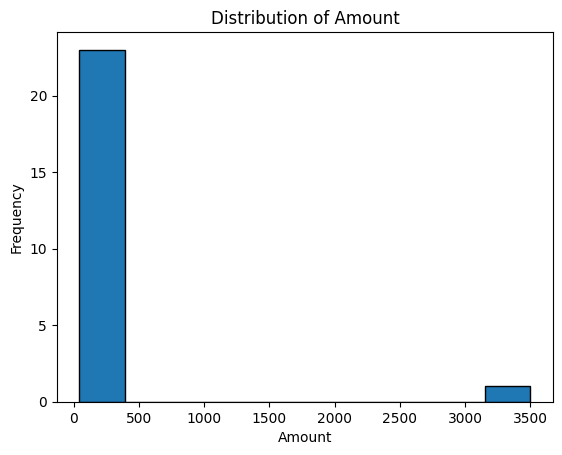

In [20]:
df_merged["amount"].plot(
    kind="hist",
    bins=10,
    edgecolor="black"
)

plt.title("Distribution of Amount")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.show()

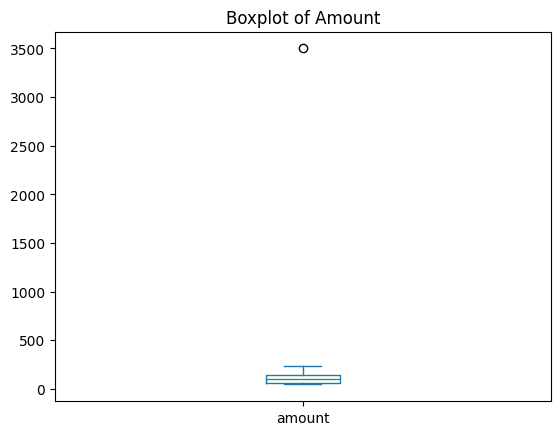

In [21]:
df_merged["amount"].plot(
    kind="box"
)

plt.title("Boxplot of Amount")

plt.show()

The histogram shows a right-skewed distribution because there is one very large amount compared to the rest of the data and the boxplot also shows this value as an outlier so that's why the plots look squashed because the large bulk order dominates the scale

In [22]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df_merged[
    (df_merged["amount"] < lower_bound) |
    (df_merged["amount"] > upper_bound)
]

print(outliers)

    sale_id store_id book_id  quantity   sale_date                 title  \
14     2003       S3     B04        25  2026-05-04  Python for Beginners   

    price       genre         store_name    city  amount  
14    140  Nonfiction  BookNook Downtown  Dammam    3500  


One outlier was detected using the 1.5×IQR rule and I decided to keep it because it represents a real bulk order not a data entry error so removing it would affect the analysis of the sales data and a log transformation could be used to reduce its impact on the distribution while keeping all the data

1. Dammam had the highest total sales (3965), while Riyadh and Jeddah had much lower totals (965 and 1000) as shown by the groupby results

2. The mean amount (247.08) is much higher than the median (102.5) and the distribution is right-skewed

3. The histogram and boxplot show one very large bulk order and appears as an outlier

4. One outlier was detected using the 1.5×IQR rule and it was kept because it represents a real bulk order rather than a data entry error